In [ ]:
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')
path = "/content/drive/MyDrive/Huntington_Disease_Dataset_Preprocessed_Scaled.csv"
df = pd.read_csv(path)
print("DataSet loaded:",df.shape)

Mounted at /content/drive
DataSet loaded: (48536, 28)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Epoch 1/20 | Accuracy: 0.3321 | Loss: nan
Epoch 2/20 | Accuracy: 0.3321 | Loss: nan
Epoch 3/20 | Accuracy: 0.3321 | Loss: nan
Epoch 4/20 | Accuracy: 0.3321 | Loss: nan
Epoch 5/20 | Accuracy: 0.3321 | Loss: nan
Epoch 6/20 | Accuracy: 0.3321 | Loss: nan
Epoch 7/20 | Accuracy: 0.3321 | Loss: nan
Epoch 8/20 | Accuracy: 0.3321 | Loss: nan
Epoch 9/20 | Accuracy: 0.3321 | Loss: nan
Epoch 10/20 | Accuracy: 0.3321 | Loss: nan
Epoch 11/20 | Accuracy: 0.3321 | Loss: nan
Epoch 12/20 | Accuracy: 0.3321 | Loss: nan
Epoch 13/20 | Accuracy: 0.3321 | Loss: nan
Epoch 14/20 | Accuracy: 0.3321 | Loss: nan
Epoch 15/20 | Accuracy: 0.3321 | Loss: nan
Epoch 16/20 | Accuracy: 0.3321 | Loss: nan
Epoch 17/20 | Accuracy: 0.3321 | Loss: nan
Epoch 18/20 | Accuracy: 0.3321 | Loss: nan
Epoch 19/20 | Accuracy: 0.3321 | Loss: nan
Epoch 20/20 | Accuracy: 0.3321 | Loss: nan

===== FINAL METRICS =====
Accuracy : 0.3321
Precision: 0.1107
Recall   : 0.3333
F1-score : 0.1662


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


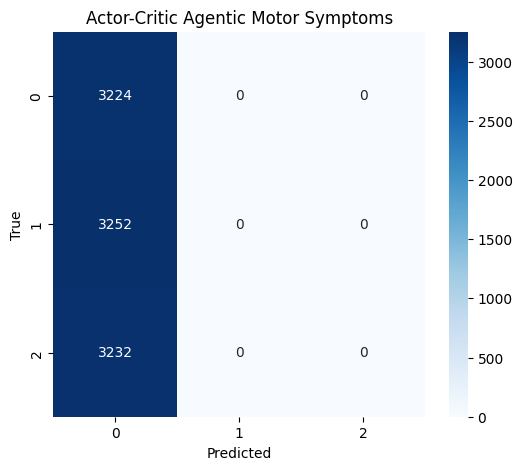

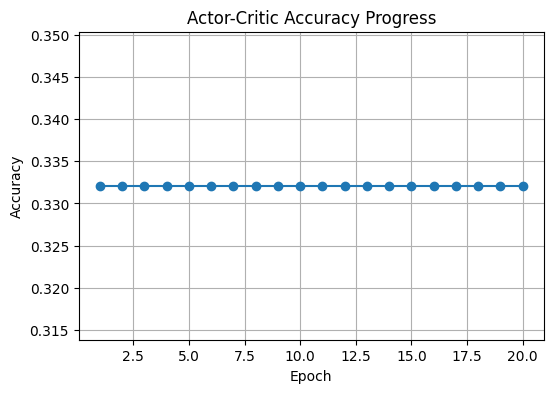

In [ ]:
# =========================================
# Actor-Critic Agentic MLP for Motor Symptoms
# =========================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------
# 1. DATA PREPROCESSING
# -----------------------------------------

# Load your dataset
# df = pd.read_csv("your_dataset.csv")
df = df.drop(columns=["Patient_ID"])
df = df.apply(pd.to_numeric, errors="coerce")
df = df.fillna(df.median())

X = df.drop(columns=["Motor_Symptoms"]).astype(np.float32).values
y = df["Motor_Symptoms"].astype(int).values - 1  # 0-index for PyTorch

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# -----------------------------------------
# 2. MLP MODEL
# -----------------------------------------

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size=128, output_size=3, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, output_size)
        )
    def forward(self, x):
        return self.net(x)

# -----------------------------------------
# 3. ACTOR & CRITIC
# -----------------------------------------

class Actor(nn.Module):
    def __init__(self, state_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()  # action scale (0-1)
        )
    def forward(self, x):
        return self.net(x)

class Critic(nn.Module):
    def __init__(self, state_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

# -----------------------------------------
# 4. TRAINING SETTINGS
# -----------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_size = X_train.shape[1]

mlp = MLP(input_size).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer_mlp = optim.Adam(mlp.parameters(), lr=0.001)

actor = Actor(state_dim=2).to(device)   # state = [loss, accuracy]
critic = Critic(state_dim=2).to(device)
actor_optim = optim.Adam(actor.parameters(), lr=0.001)
critic_optim = optim.Adam(critic.parameters(), lr=0.002)

BATCH_SIZE = 32
EPOCHS = 20
accuracy_list = []

train_loader = DataLoader(TensorDataset(torch.tensor(X_train).float(),
                                        torch.tensor(y_train).long()),
                          batch_size=BATCH_SIZE, shuffle=True)

# -----------------------------------------
# 5. ACTOR-CRITIC TRAINING LOOP
# -----------------------------------------

for epoch in range(EPOCHS):
    mlp.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_mlp.zero_grad()
        logits = mlp(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer_mlp.step()

    # Evaluate
    mlp.eval()
    with torch.no_grad():
        logits = mlp(torch.tensor(X_test).float().to(device))
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        acc = accuracy_score(y_test, preds)
        test_loss = loss_fn(logits, torch.tensor(y_test).to(device)).item()
        accuracy_list.append(acc)

    # ---- Actor-Critic Update ----
    state = torch.tensor([[test_loss, acc]], dtype=torch.float32).to(device)
    action = actor(state)
    value = critic(state)
    reward = acc  # reward = accuracy

    advantage = reward - value
    critic_loss = advantage.pow(2)
    actor_loss = -torch.log(action) * advantage.detach()

    actor_optim.zero_grad()
    actor_loss.backward()
    actor_optim.step()

    critic_optim.zero_grad()
    critic_loss.backward()
    critic_optim.step()

    print(f"Epoch {epoch+1}/{EPOCHS} | Accuracy: {acc:.4f} | Loss: {test_loss:.4f}")

# -----------------------------------------
# 6. FINAL METRICS
# -----------------------------------------

precision = precision_score(y_test, preds, average="macro")
recall = recall_score(y_test, preds, average="macro")
f1 = f1_score(y_test, preds, average="macro")

print("\n===== FINAL METRICS =====")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Actor-Critic Agentic Motor Symptoms")
plt.show()

# Accuracy vs Epochs
plt.figure(figsize=(6,4))
plt.plot(range(1, EPOCHS+1), accuracy_list, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Actor-Critic Accuracy Progress")
plt.grid(True)
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Epoch 1/20 | Accuracy: 0.2511 | F1: 0.1004
Epoch 2/20 | Accuracy: 0.2511 | F1: 0.1004
Epoch 3/20 | Accuracy: 0.2511 | F1: 0.1004
Epoch 4/20 | Accuracy: 0.2511 | F1: 0.1004
Epoch 5/20 | Accuracy: 0.2511 | F1: 0.1004
Epoch 6/20 | Accuracy: 0.2511 | F1: 0.1004
Epoch 7/20 | Accuracy: 0.2511 | F1: 0.1004
Epoch 8/20 | Accuracy: 0.2511 | F1: 0.1004
Epoch 9/20 | Accuracy: 0.2511 | F1: 0.1004
Epoch 10/20 | Accuracy: 0.2511 | F1: 0.1004
Epoch 11/20 | Accuracy: 0.2511 | F1: 0.1004
Epoch 12/20 | Accuracy: 0.2511 | F1: 0.1004
Epoch 13/20 | Accuracy: 0.2511 | F1: 0.1004
Epoch 14/20 | Accuracy: 0.2511 | F1: 0.1004
Epoch 15/20 | Accuracy: 0.2511 | F1: 0.1004
Epoch 16/20 | Accuracy: 0.2511 | F1: 0.1004
Epoch 17/20 | Accuracy: 0.2511 | F1: 0.1004
Epoch 18/20 | Accuracy: 0.2511 | F1: 0.1004
Epoch 19/20 | Accuracy: 0.2511 | F1: 0.1004
Epoch 20/20 | Accuracy: 0.2511 | F1: 0.1004

===== FINAL DISEASE STAGE METRICS =====
Accuracy : 0.2511
Precision: 0.0628
Recall   : 0.2500
F1-score : 0.1004


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


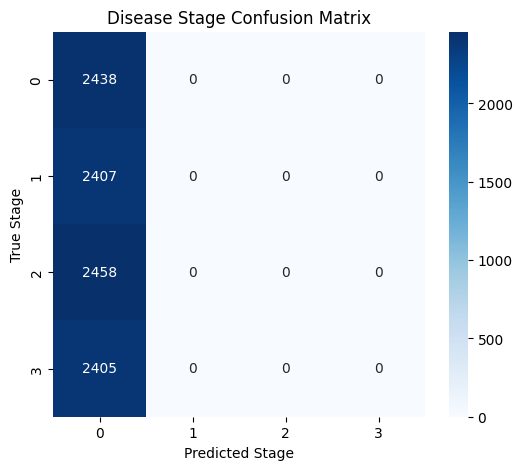

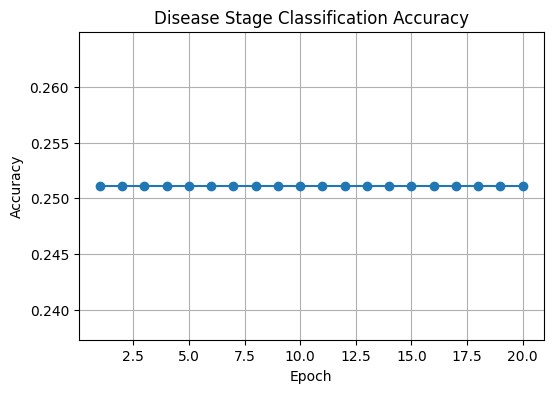

In [ ]:
# =========================================
# Actor-Critic Agentic MLP for Disease Stage Classification
# =========================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------
# 1. DATA PREPROCESSING
# -----------------------------------------

# df = pd.read_csv("your_dataset.csv")

df = df.drop(columns=["Patient_ID"], errors='ignore') # Added errors='ignore'
df = df.apply(pd.to_numeric, errors="coerce")
df = df.fillna(df.median())

X = df.drop(columns=["Disease_Stage"]).astype(np.float32).values

# Fix: Map unique disease stages to a contiguous, zero-indexed range
unique_disease_stages = sorted(df["Disease_Stage"].astype(int).unique())
stage_to_idx = {stage: idx for idx, stage in enumerate(unique_disease_stages)}
y = df["Disease_Stage"].astype(int).map(stage_to_idx).values

num_classes = len(unique_disease_stages) # Recalculate based on actual number of unique stages

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# -----------------------------------------
# 2. MLP MODEL
# -----------------------------------------

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size=128, output_size=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        return self.net(x)

# -----------------------------------------
# 3. ACTOR & CRITIC
# -----------------------------------------

class Actor(nn.Module):
    def __init__(self, state_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

class Critic(nn.Module):
    def __init__(self, state_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

# -----------------------------------------
# 4. TRAINING SETTINGS
# -----------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mlp = MLP(input_size=X_train.shape[1], output_size=num_classes).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer_mlp = optim.Adam(mlp.parameters(), lr=0.001)

actor = Actor().to(device)
critic = Critic().to(device)

actor_optim = optim.Adam(actor.parameters(), lr=0.001)
critic_optim = optim.Adam(critic.parameters(), lr=0.002)

BATCH_SIZE = 32
EPOCHS = 20
accuracy_list = []

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=BATCH_SIZE,
    shuffle=True
)

# -----------------------------------------
# 5. ACTOR-CRITIC TRAINING LOOP
# -----------------------------------------

for epoch in range(EPOCHS):
    mlp.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer_mlp.zero_grad()
        logits = mlp(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer_mlp.step()

    # ----- Evaluation -----
    mlp.eval()
    with torch.no_grad():
        logits = mlp(torch.tensor(X_test).to(device))
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        acc = accuracy_score(y_test, preds)
        f1  = f1_score(y_test, preds, average="macro")
        test_loss = loss_fn(logits, torch.tensor(y_test).to(device)).item()

        accuracy_list.append(acc)

    # ----- Actor-Critic Update -----
    state = torch.tensor([[test_loss, acc]], dtype=torch.float32).to(device)
    action = actor(state)
    value = critic(state)

    reward = 0.7 * acc + 0.3 * f1
    advantage = reward - value

    critic_loss = advantage.pow(2)
    actor_loss = -torch.log(action + 1e-8) * advantage.detach()

    actor_optim.zero_grad()
    actor_loss.backward()
    actor_optim.step()

    critic_optim.zero_grad()
    critic_loss.backward()
    critic_optim.step()

    print(f"Epoch {epoch+1}/{EPOCHS} | Accuracy: {acc:.4f} | F1: {f1:.4f}")

# -----------------------------------------
# 6. FINAL METRICS
# -----------------------------------------

precision = precision_score(y_test, preds, average="macro")
recall    = recall_score(y_test, preds, average="macro")
f1        = f1_score(y_test, preds, average="macro")

print("\n===== FINAL DISEASE STAGE METRICS =====")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# -----------------------------------------
# 7. VISUALIZATIONS
# -----------------------------------------

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Stage")
plt.ylabel("True Stage")
plt.title("Disease Stage Confusion Matrix")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(range(1, EPOCHS+1), accuracy_list, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Disease Stage Classification Accuracy")
plt.grid(True)
plt.show()

Epoch 1/20 | Accuracy: 0.3296
Epoch 2/20 | Accuracy: 0.3306
Epoch 3/20 | Accuracy: 0.3323
Epoch 4/20 | Accuracy: 0.3309
Epoch 5/20 | Accuracy: 0.3288
Epoch 6/20 | Accuracy: 0.3312
Epoch 7/20 | Accuracy: 0.3417
Epoch 8/20 | Accuracy: 0.3259
Epoch 9/20 | Accuracy: 0.3310
Epoch 10/20 | Accuracy: 0.3294
Epoch 11/20 | Accuracy: 0.3295
Epoch 12/20 | Accuracy: 0.3288
Epoch 13/20 | Accuracy: 0.3288
Epoch 14/20 | Accuracy: 0.3275
Epoch 15/20 | Accuracy: 0.3276
Epoch 16/20 | Accuracy: 0.3334
Epoch 17/20 | Accuracy: 0.3325
Epoch 18/20 | Accuracy: 0.3353
Epoch 19/20 | Accuracy: 0.3240
Epoch 20/20 | Accuracy: 0.3247

===== FINAL METRICS =====
Accuracy : 0.3247
Precision: 0.3249
Recall   : 0.3248
F1-score : 0.3185


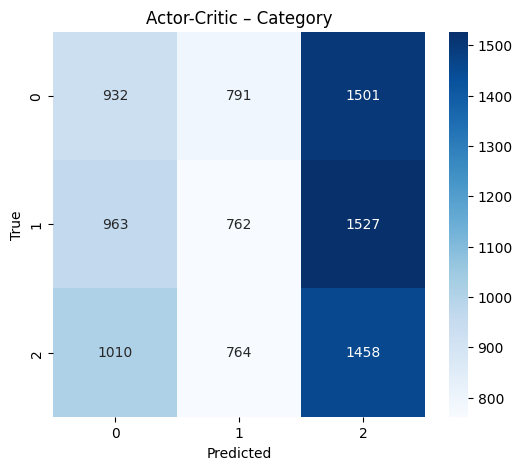

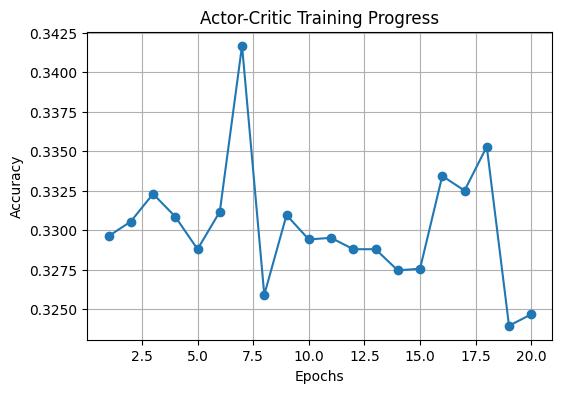

In [ ]:
# =========================================
# Actor-Critic Agentic Category
# =========================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------
# 1. DATA PREPROCESSING
# -----------------------------------------

# Drop non-informative ID
df = df.drop(columns=["Patient_ID"], errors="ignore")

# Separate target
target_col = "Motor_Symptoms"

# Encode target (categorical classes)
label_encoder = LabelEncoder()
df[target_col] = label_encoder.fit_transform(df[target_col])

# Separate features
X = df.drop(columns=[target_col])
y = df[target_col].values

# Handle categorical FEATURES
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols   = X.select_dtypes(exclude=["object"]).columns

# Encode categorical features
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Fill missing values
X[numerical_cols] = X[numerical_cols].fillna(X[numerical_cols].median())
X = X.fillna(0)

X = X.astype(np.float32)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, stratify=y, random_state=42
)

# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

num_classes = len(np.unique(y))

# -----------------------------------------
# 2. MLP MODEL
# -----------------------------------------

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size=128, output_size=num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        return self.net(x)

# -----------------------------------------
# 3. ACTOR & CRITIC
# -----------------------------------------

class Actor(nn.Module):
    def __init__(self, state_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

class Critic(nn.Module):
    def __init__(self, state_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

# -----------------------------------------
# 4. TRAINING SETUP
# -----------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mlp = MLP(input_size=X_train.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer_mlp = optim.Adam(mlp.parameters(), lr=0.001)

actor = Actor().to(device)
critic = Critic().to(device)

actor_optim  = optim.Adam(actor.parameters(), lr=0.001)
critic_optim = optim.Adam(critic.parameters(), lr=0.002)

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=32,
    shuffle=True
)

EPOCHS = 20
accuracy_list = []

# -----------------------------------------
# 5. TRAINING LOOP
# -----------------------------------------

for epoch in range(EPOCHS):
    mlp.train()

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer_mlp.zero_grad()
        logits = mlp(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer_mlp.step()

    # Evaluation
    mlp.eval()
    with torch.no_grad():
        logits = mlp(torch.tensor(X_test).to(device))
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        acc = accuracy_score(y_test, preds)
        test_loss = criterion(logits, torch.tensor(y_test).to(device)).item()
        accuracy_list.append(acc)

    # Actor-Critic Update
    state = torch.tensor([[test_loss, acc]], dtype=torch.float32).to(device)
    value = critic(state)
    action = actor(state)
    reward = acc

    advantage = reward - value
    actor_loss  = -torch.log(action + 1e-8) * advantage.detach()
    critic_loss = advantage.pow(2)

    actor_optim.zero_grad()
    actor_loss.backward()
    actor_optim.step()

    critic_optim.zero_grad()
    critic_loss.backward()
    critic_optim.step()

    print(f"Epoch {epoch+1}/{EPOCHS} | Accuracy: {acc:.4f}")

# -----------------------------------------
# 6. FINAL METRICS
# -----------------------------------------

precision = precision_score(y_test, preds, average="macro")
recall    = recall_score(y_test, preds, average="macro")
f1        = f1_score(y_test, preds, average="macro")

print("\n===== FINAL METRICS =====")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Actor-Critic – Category")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Accuracy Curve
plt.figure(figsize=(6,4))
plt.plot(range(1, EPOCHS+1), accuracy_list, marker="o")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Actor-Critic Training Progress")
plt.grid(True)
plt.show()
